In [11]:
import numpy as np
import matplotlib.pyplot as plt 

from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [12]:
X_train = X_train/255
X_test = X_test/255

In [13]:
from tensorflow.keras.utils import to_categorical
y_train_cod = to_categorical(y_train)
y_test_cod = to_categorical(y_test)

In [14]:
from keras.models import Sequential
modelo = Sequential(name="moda")

In [15]:
X_train.shape

(60000, 28, 28)

In [16]:
from keras.layers import Conv2D, MaxPool2D, AvgPool2D, Flatten, Dense

modelo.add(Conv2D(
    10,
    3,
    input_shape=(28,28,1),
    activation="relu",
    name="conv_1"
))

modelo.add(AvgPool2D(name="pool_1", pool_size=(3,3)))

modelo.add(Conv2D(
    10,
    4,
    activation="relu",
    name="conv_2"
))

modelo.add(AvgPool2D(name="pool_2", pool_size=(3,3)))

modelo.add(Flatten())

In [17]:
modelo.add(Dense(1000,activation="relu"))
modelo.add(Dense(10, activation="softmax"))

modelo.summary()

Model: "moda"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (AveragePooling2D)       │ (None, 8, 8, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 5, 5, 10)       │         1,610 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (AveragePooling2D)       │ (None, 1, 1, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,720 (88.75 KB)

 Trainable params: 22,720 (88.75 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
modelo.compile(
    loss='categorical_crossentropy',
    optimizer='adam', #probar otros optimizadores
    metrics=['accuracy']
    )

In [19]:
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

In [20]:
h = modelo.fit(
    X_train, y_train_cod,
    epochs=20,
    #si no se especifica bach_size es 32 por defecto
    verbose=True
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6864 - loss: 0.8373
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7594 - loss: 0.6420
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7783 - loss: 0.5919
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7897 - loss: 0.5599
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8011 - loss: 0.5325
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8091 - loss: 0.5116
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8164 - loss: 0.4934
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8218 - loss: 0.4774
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8273 - loss: 0.4652
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8319 - loss: 0.4524
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8340 - loss: 0.4447
Epoch 12/20
1875/1875 ━━━━━━━━

In [21]:
#Evaluación del modelo
test_loss, test_acc = modelo.evaluate(X_test, y_test_cod)
print("Test loss", test_loss)
print("Test accuracy", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8433 - loss: 0.4273
Test loss 0.42726194858551025
Test accuracy 0.8432999849319458


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


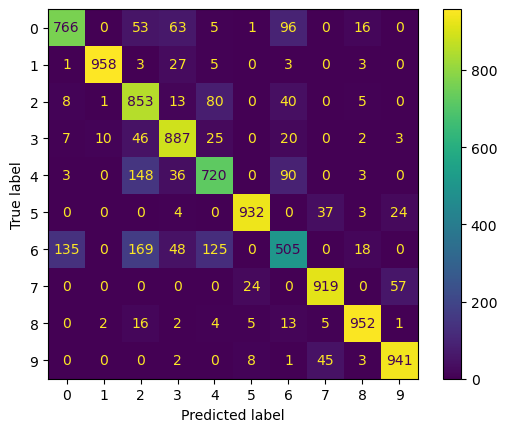

In [22]:
#Vemos la matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = modelo.predict(X_test)
y_pred = [np.argmax(y) for y in y_pred]
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import ConfusionMatrixDisplay
mcd = ConfusionMatrixDisplay(cm)
mcd.plot()

In [23]:
modelo.save("modelo_zalando.keras")